In [1]:
# Mount the Google Drive to Google Colab
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 92.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 8.4 MB/s eta 0:00:00


In [3]:
import ultralytics
ultralytics.checks()

Ultralytics 8.4.142 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.3/112.6 GB disk)


In [4]:
# Training the model
!yolo task=segment \
    mode=train \
    model=yolov8n-seg.pt \
    data=/content/drive/MyDrive/Video_Segmentation_Study/Video_Segmentation_Study02/VehicleSegmentation/dataset.yaml \
    epochs=20 \
    imgsz=640 \
    batch=5 \
    project=/content/drive/MyDrive/Video_Segmentation_Study/Video_Segmentation_Study02/VehicleSegmentation/TrainingResults \
    name=Vehicle

Ultralytics 8.4.142 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=5, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Video_Segmentation_Study/Video_Segmentation_Study02/VehicleSegmentation/dataset.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, 

In [13]:
# Using the trained model to do segmentaion on Images
!yolo task=segment \
    mode=predict \
    model=/content/drive/MyDrive/Video_Segmentation_Study/Video_Segmentation_Study02/VehicleSegmentation/TrainingResults/Vehicle-6/weights/best.pt \
    conf=0.55 \
    source=/content/drive/MyDrive/Video_Segmentation_Study/Video_Segmentation_Study02/VehicleTestImages

Ultralytics 8.4.142 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-seg summary (fused): 85 layers, 3,259,234 parameters, 0 gradients, 11.3 GFLOPs

image 1/3 /content/drive/MyDrive/Video_Segmentation_Study/Video_Segmentation_Study02/VehicleTestImages/image_1.jpg: 640x640 1 car, 4 motorbike-bikes, 9.2ms
image 2/3 /content/drive/MyDrive/Video_Segmentation_Study/Video_Segmentation_Study02/VehicleTestImages/image_2.jpg: 640x640 9 cars, 1 motorbike-bike, 9.2ms
image 3/3 /content/drive/MyDrive/Video_Segmentation_Study/Video_Segmentation_Study02/VehicleTestImages/image_3.jpg: 640x640 1 car, 6 motorbike-bikes, 10.0ms
Speed: 11.8ms preprocess, 9.5ms inference, 10.7ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/segment/predict-3
💡 Learn more at https://docs.ultralytics.com/modes/predict


In [14]:
# Storing the segmented images in google drive
!cp -r /content/runs/segment/predict-3 /content/drive/MyDrive/Video_Segmentation_Study/Video_Segmentation_Study02/VehicleTestImagesSegmented

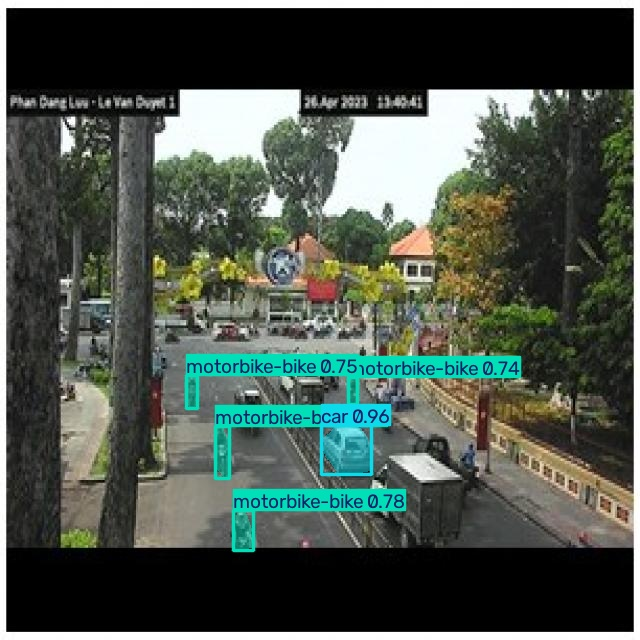

In [15]:
# Displaying one of the result
from IPython.display import Image
Image('/content/drive/MyDrive/Video_Segmentation_Study/Video_Segmentation_Study02/VehicleTestImagesSegmented/predict-3/image_1.jpg')

In [26]:
# Using the trained model to do segmentaion on Videos
!yolo task=segment \
    mode=predict \
    model=/content/drive/MyDrive/Video_Segmentation_Study/Video_Segmentation_Study02/VehicleSegmentation/TrainingResults/Vehicle-6/weights/best.pt \
    conf=0.55 \
    source=/content/drive/MyDrive/Video_Segmentation_Study/Video_Segmentation_Study02/VehicleTestVideos

Ultralytics 8.4.142 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-seg summary (fused): 85 layers, 3,259,234 parameters, 0 gradients, 11.3 GFLOPs

video 1/1 (frame 1/716) /content/drive/MyDrive/Video_Segmentation_Study/Video_Segmentation_Study02/VehicleTestVideos/Cars_On_Road.mp4: 384x640 2 cars, 7.7ms
video 1/1 (frame 2/716) /content/drive/MyDrive/Video_Segmentation_Study/Video_Segmentation_Study02/VehicleTestVideos/Cars_On_Road.mp4: 384x640 2 cars, 9.2ms
video 1/1 (frame 3/716) /content/drive/MyDrive/Video_Segmentation_Study/Video_Segmentation_Study02/VehicleTestVideos/Cars_On_Road.mp4: 384x640 2 cars, 8.0ms
video 1/1 (frame 4/716) /content/drive/MyDrive/Video_Segmentation_Study/Video_Segmentation_Study02/VehicleTestVideos/Cars_On_Road.mp4: 384x640 2 cars, 8.9ms
video 1/1 (frame 5/716) /content/drive/MyDrive/Video_Segmentation_Study/Video_Segmentation_Study02/VehicleTestVideos/Cars_On_Road.mp4: 384x640 2 cars, 8.8ms
video 1/1 (frame 6/716) /content/drive/MyDr

In [27]:
# Storing the segmented videos in google drive
!cp -r /content/runs/segment/predict-5 /content/drive/MyDrive/Video_Segmentation_Study/Video_Segmentation_Study02/VehicleTestVideosSegmented

In [28]:
# Converting one of the videos to mp4 format for display
# (Natively segmented video is stored as .avi which our poor collab cannot play)
!ffmpeg -y -i /content/drive/MyDrive/Video_Segmentation_Study/Video_Segmentation_Study02/VehicleTestVideosSegmented/predict-5/Cars_On_Road.avi -vcodec libx264 /content/drive/MyDrive/Video_Segmentation_Study/Video_Segmentation_Study02/VehicleTestVideosSegmented/converted_video.mp4

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [29]:
# Displaying one of the segmented videos
from IPython.display import Video

video_path = '/content/drive/MyDrive/Video_Segmentation_Study/Video_Segmentation_Study02/VehicleTestVideosSegmented/converted_video.mp4'

Video(video_path, embed=True, width=640)